# EDA Distribusi Kelas — 6 Dataset Grading Diabetic Retinopathy

Notebook ini menghitung **distribusi jumlah citra per kelas ICDR (0-4)** untuk keenam dataset
(IDRiD, DDR, APTOS 2019, Messidor-2, EyePACS, DeepDRiD), lalu menilai **seberapa seimbang** tiap dataset
dan meng-generate **tabel LaTeX** siap tempel ke proposal.

Menjawab revisi penguji: *"tuliskan lebih detil datasetnya, brp data citra/kelas ... laporkan apa adanya,
enggak harus seimbang."*

**Cara pakai:**
1. Unduh **file label saja** tiap dataset ke `labels/<dataset>/` (lihat `README_download_labels.md`).
2. Run all. Dataset yang filenya belum ada akan **di-skip otomatis** (tidak error).
3. Output tersimpan di `output/`: CSV distribusi, PNG plot, dan `.tex` tabel untuk proposal.

Skala ICDR: 0 = No DR · 1 = Mild NPDR · 2 = Moderate NPDR · 3 = Severe NPDR · 4 = PDR.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['savefig.dpi'] = 200
mpl.rcParams['savefig.bbox'] = 'tight'

BASE = Path('labels')
OUT = Path('output'); OUT.mkdir(exist_ok=True)

GRADES = [0, 1, 2, 3, 4]
GRADE_NAMES = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'PDR'}
# Urutan tampil dataset (dari kecil/homogen ke besar/heterogen)
DATASET_ORDER = ['IDRiD', 'DeepDRiD', 'Messidor-2', 'APTOS 2019', 'DDR', 'EyePACS']

## 1. Konfigurasi path & nama kolom

Sesuaikan **hanya jika** nama file/kolom di komputermu berbeda. Kalau kolom grade tidak ketemu, loader
akan mencetak daftar kolom yang tersedia supaya mudah dibetulkan di sini.

In [2]:
CONFIG = {
    'IDRiD': {
        'type': 'csv',
        'files': {
            'train': BASE / 'idrid' / 'a. IDRiD_Disease Grading_Training Labels.csv',
            'test':  BASE / 'idrid' / 'b. IDRiD_Disease Grading_Testing Labels.csv',
        },
        'grade_col': 'Retinopathy grade',
        'image_col': 'Image name',
    },
    'DDR': {
        'type': 'txt',  # baris: '<image>.jpg <grade>' ; grade 5 = ungradable (dibuang)
        'files': {
            'train': BASE / 'ddr' / 'train.txt',
            'valid': BASE / 'ddr' / 'valid.txt',
            'test':  BASE / 'ddr' / 'test.txt',
        },
        'drop_grades': [5],
    },
    'APTOS 2019': {
        'type': 'csv',
        'files': {'train': BASE / 'aptos2019' / 'train.csv'},
        'grade_col': 'diagnosis',
        'image_col': 'id_code',
    },
    'Messidor-2': {
        'type': 'csv',
        'files': {'all': BASE / 'messidor2' / 'messidor_data.csv'},
        'grade_col': ['adjudicated_dr_grade', 'dr_grade', 'diagnosis'],  # NaN = ungradable
        'image_col': 'image_id',
    },
    'EyePACS': {
        'type': 'csv',
        'files': {
            'train': BASE / 'eyepacs' / 'trainLabels.csv',
            'test':  BASE / 'eyepacs' / 'testLabels15.csv',  # 2015 test split (mirror)
        },
        'grade_col': 'level',
        'image_col': 'image',
    },
    'DeepDRiD': {
        'type': 'deepdrid',  # label per-mata -> image-level via suffix _l/_r pada image_id
        'files': {
            'train': BASE / 'deepdrid' / 'regular-fundus-training.csv',
            'valid': BASE / 'deepdrid' / 'regular-fundus-validation.csv',
            'test':  BASE / 'deepdrid' / 'regular-fundus-test.csv',
        },
        'one_field_per_eye': True,  # sesuai desain proposal: satu bidang per mata
    },
}

## 2. Loader (tahan-error)

Setiap dataset dimuat ke bentuk seragam `['image', 'grade', 'split']`. DeepDRiD ditangani khusus karena
labelnya per mata.

In [3]:
def _resolve_grade_col(df, grade_col):
    cands = grade_col if isinstance(grade_col, (list, tuple)) else [grade_col]
    for c in cands:
        if c in df.columns:
            return c
    raise KeyError(f"kolom grade {cands} tidak ada. Kolom tersedia: {list(df.columns)}")


def _load_csv_split(path, grade_col, image_col, split):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    gcol = _resolve_grade_col(df, grade_col)
    out = pd.DataFrame({'grade': df[gcol]})
    out['image'] = df[image_col] if image_col in df.columns else np.arange(len(df))
    out['split'] = split
    return out


def _load_txt_split(path, split):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=['image', 'grade'])
    df['split'] = split
    return df


def _load_deepdrid(cfg):
    frames = []
    for split, path in cfg['files'].items():
        path = Path(path)
        if not path.exists():
            continue
        df = pd.read_csv(path)
        iid = df['image_id'].astype(str)
        if 'left_eye_DR_Level' in df.columns:  # train/val: label per-mata
            grade = np.where(iid.str.contains(r'_l\d'), df['left_eye_DR_Level'],
                             np.where(iid.str.contains(r'_r\d'), df['right_eye_DR_Level'], np.nan))
        else:  # test set: grade langsung per-citra (kolom DR_Levels)
            gcol = next((c for c in ['DR_Levels', 'DR_level', 'grade'] if c in df.columns), df.columns[1])
            grade = df[gcol].values
        sub = pd.DataFrame({'image': iid, 'grade': grade, 'split': split})
        sub['field'] = iid.str.extract(r'_[lr](\d)')[0]
        frames.append(sub)
    if not frames:
        return None
    df = pd.concat(frames, ignore_index=True)
    if cfg.get('one_field_per_eye'):
        df = df[df['field'] == '1']
    return df[['image', 'grade', 'split']]


def load_dataset(name, cfg):
    """Kembalikan DataFrame ['image','grade','split'] atau None bila file belum ada."""
    if cfg['type'] == 'deepdrid':
        df = _load_deepdrid(cfg)
    else:
        frames = []
        for split, path in cfg['files'].items():
            path = Path(path)
            if not path.exists():
                continue
            try:
                if cfg['type'] == 'csv':
                    frames.append(_load_csv_split(path, cfg['grade_col'], cfg.get('image_col', ''), split))
                else:
                    frames.append(_load_txt_split(path, split))
            except Exception as e:
                print(f"  [!] {name}/{split}: gagal baca ({e})")
        df = pd.concat(frames, ignore_index=True) if frames else None
    if df is None or len(df) == 0:
        print(f"  [-] {name}: file label belum ada -> di-skip")
        return None
    df['grade'] = pd.to_numeric(df['grade'], errors='coerce')
    n0 = len(df)
    df = df.dropna(subset=['grade'])
    df['grade'] = df['grade'].astype(int)
    for g in cfg.get('drop_grades', []):
        df = df[df['grade'] != g]
    df = df[df['grade'].isin(GRADES)]
    dropped = n0 - len(df)
    tag = f" ({dropped} baris ungradable/NaN dibuang)" if dropped else ""
    print(f"  [+] {name}: {len(df)} citra dari split {sorted(df['split'].unique())}{tag}")
    return df


print('Memuat dataset yang tersedia...')
data = {}
for name in DATASET_ORDER:
    d = load_dataset(name, CONFIG[name])
    if d is not None:
        data[name] = d
print(f"\nDataset termuat: {list(data.keys()) or 'BELUM ADA (unduh dulu file label)'}")

Memuat dataset yang tersedia...
  [+] IDRiD: 516 citra dari split ['test', 'train']
  [+] DeepDRiD: 994 citra dari split ['test', 'train', 'valid']
  [+] Messidor-2: 1744 citra dari split ['all'] (4 baris ungradable/NaN dibuang)
  [+] APTOS 2019: 3662 citra dari split ['train']
  [+] DDR: 12522 citra dari split ['test', 'train', 'valid'] (1151 baris ungradable/NaN dibuang)
  [+] EyePACS: 88702 citra dari split ['test', 'train']

Dataset termuat: ['IDRiD', 'DeepDRiD', 'Messidor-2', 'APTOS 2019', 'DDR', 'EyePACS']


## 3. Tabel distribusi jumlah citra per kelas

In [4]:
def class_counts(df):
    return df['grade'].value_counts().reindex(GRADES, fill_value=0).astype(int)

rows = []
for name in DATASET_ORDER:
    if name not in data:
        continue
    c = class_counts(data[name])
    row = {'Dataset': name}
    row.update({f'Grade {g}': int(c[g]) for g in GRADES})
    row['Total'] = int(c.sum())
    rows.append(row)

counts_df = pd.DataFrame(rows).set_index('Dataset') if rows else pd.DataFrame()
counts_df.to_csv(OUT / 'distribusi_kelas_counts.csv')
counts_df

,Grade 0,Grade 1,Grade 2,Grade 3,Grade 4,Total
Dataset,,,,,,
IDRiD,168,25,168,93,62,516
DeepDRiD,453,111,197,177,56,994
Messidor-2,1017,270,347,75,35,1744
APTOS 2019,1805,370,999,193,295,3662
DDR,6266,630,4477,236,913,12522
EyePACS,65343,6205,13153,2087,1914,88702


In [5]:
# Proporsi (%) per kelas -- memudahkan lihat dominasi kelas 0
if not counts_df.empty:
    grade_cols = [f'Grade {g}' for g in GRADES]
    prop_df = (counts_df[grade_cols].div(counts_df['Total'], axis=0) * 100).round(1)
    prop_df.to_csv(OUT / 'distribusi_kelas_persen.csv')
    display(prop_df)

,Grade 0,Grade 1,Grade 2,Grade 3,Grade 4
Dataset,,,,,
IDRiD,32.6,4.8,32.6,18.0,12.0
DeepDRiD,45.6,11.2,19.8,17.8,5.6
Messidor-2,58.3,15.5,19.9,4.3,2.0
APTOS 2019,49.3,10.1,27.3,5.3,8.1
DDR,50.0,5.0,35.8,1.9,7.3
EyePACS,73.7,7.0,14.8,2.4,2.2


## 4. Metrik kesetimbangan (balanced atau tidak?)

- **Imbalance Ratio (IR)** = jumlah kelas terbesar / kelas terkecil (>1). Makin besar makin timpang.
- **% kelas mayoritas** = porsi kelas terbanyak (biasanya Grade 0).
- **Balance score** = entropi Shannon ternormalisasi (0 = semua di satu kelas, 1 = sempurna merata).
- **Label**: IR < 3 relatif seimbang · 3-10 timpang sedang · > 10 sangat timpang (long-tailed).

In [6]:
def balance_metrics(counts):
    c = counts.values.astype(float)
    total = c.sum()
    p = c / total
    nz = c[c > 0]
    ir = nz.max() / nz.min()
    maj = p.max() * 100
    pnz = p[p > 0]
    ent = -(pnz * np.log(pnz)).sum() / np.log(len(GRADES))
    min_grade = int(GRADES[int(np.argmin(np.where(c > 0, c, np.inf)))])
    if ir < 3:
        label = 'relatif seimbang'
    elif ir < 10:
        label = 'timpang sedang'
    else:
        label = 'sangat timpang (long-tailed)'
    return {'Total': int(total), 'IR (maks/min)': round(ir, 1),
            '% mayoritas': round(maj, 1), 'Balance score': round(ent, 2),
            'Kelas minoritas': f"Grade {min_grade}", 'Status': label}

brows = []
for name in DATASET_ORDER:
    if name not in data:
        continue
    m = {'Dataset': name}
    m.update(balance_metrics(class_counts(data[name])))
    brows.append(m)

balance_df = pd.DataFrame(brows).set_index('Dataset') if brows else pd.DataFrame()
balance_df.to_csv(OUT / 'metrik_kesetimbangan.csv')
balance_df

,Total,IR (maks/min),% mayoritas,Balance score,Kelas minoritas,Status
Dataset,,,,,,
IDRiD,516,6.7,32.6,0.90,Grade 1,timpang sedang
DeepDRiD,994,8.1,45.6,0.87,Grade 4,timpang sedang
Messidor-2,1744,29.1,58.3,0.71,Grade 4,sangat timpang (long-tailed)
APTOS 2019,3662,9.4,49.3,0.80,Grade 3,timpang sedang
DDR,12522,26.6,50.0,0.70,Grade 3,sangat timpang (long-tailed)
EyePACS,88702,34.1,73.7,0.54,Grade 4,sangat timpang (long-tailed)


## 5. Visualisasi

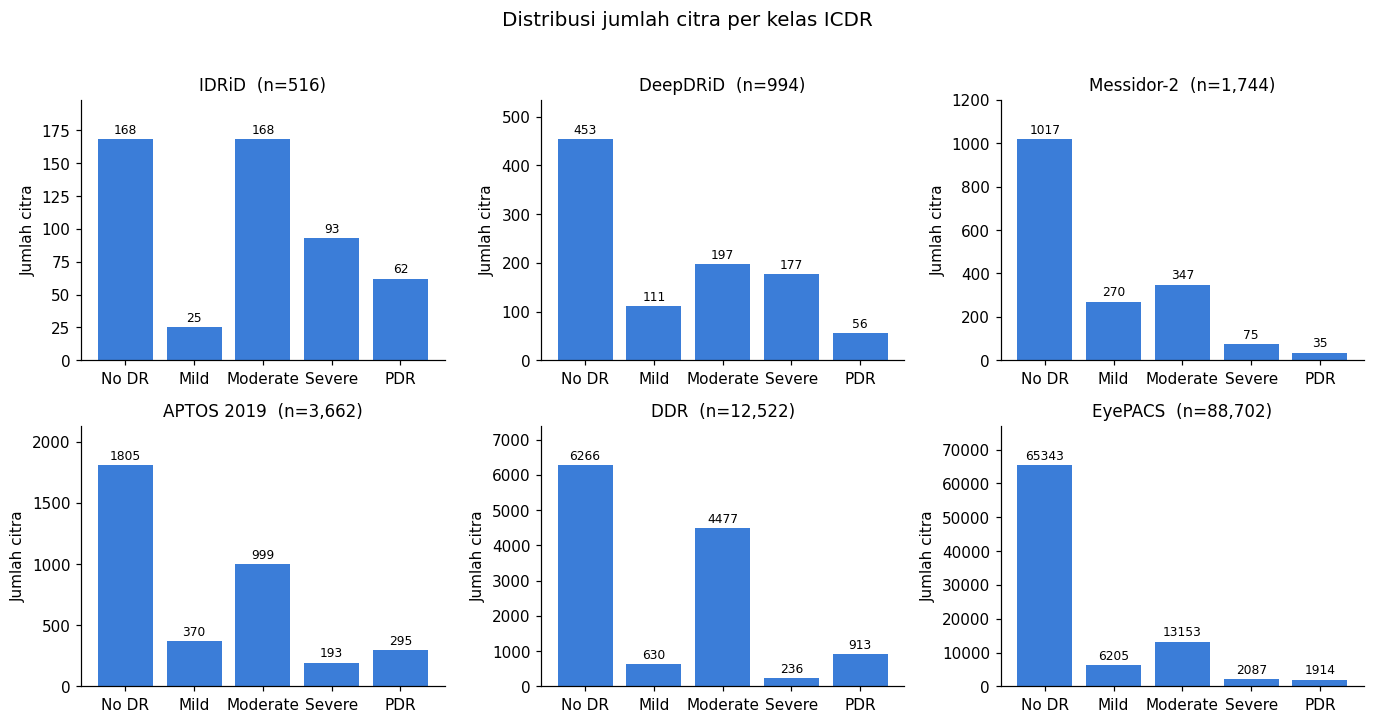

In [7]:
# 5a. Bar chart jumlah citra per kelas, satu subplot per dataset
avail = [n for n in DATASET_ORDER if n in data]
if avail:
    ncol = 3
    nrow = int(np.ceil(len(avail) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.2 * nrow))
    axes = np.array(axes).reshape(-1)
    for ax, name in zip(axes, avail):
        c = class_counts(data[name])
        bars = ax.bar([GRADE_NAMES[g] for g in GRADES], c.values, color='#3b7dd8')
        ax.set_title(f"{name}  (n={int(c.sum()):,})", fontsize=11)
        ax.set_ylabel('Jumlah citra')
        ax.bar_label(bars, fmt='%d', fontsize=8, padding=2)
        ax.margins(y=0.18)
        for s in ['top', 'right']:
            ax.spines[s].set_visible(False)
    for ax in axes[len(avail):]:
        ax.axis('off')
    fig.suptitle('Distribusi jumlah citra per kelas ICDR', fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(OUT / 'distribusi_per_dataset.png')
    plt.show()

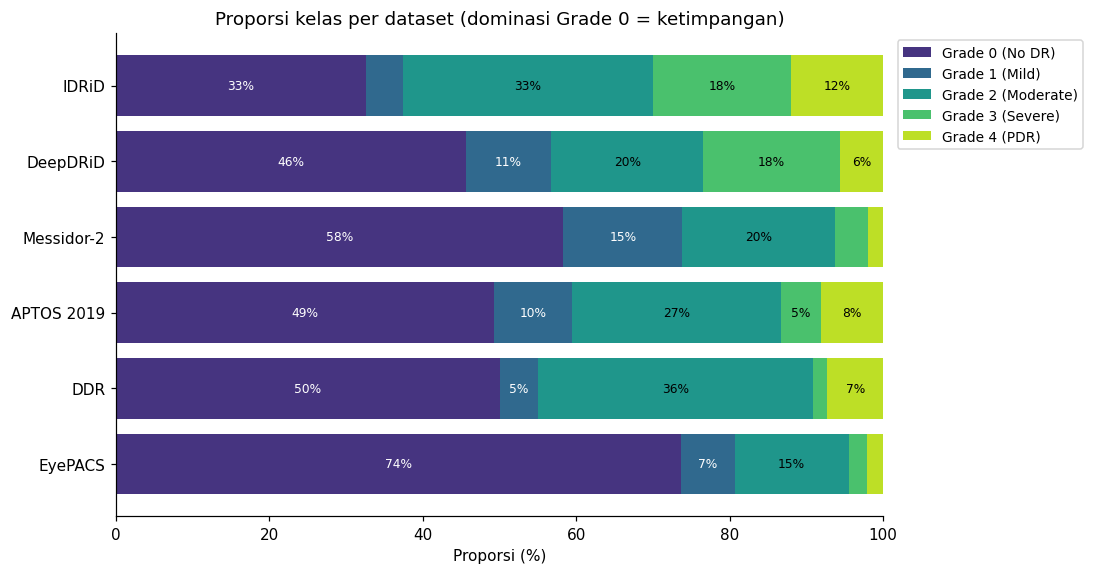

In [8]:
# 5b. Stacked proportion bar -- membandingkan bentuk ketimpangan antar dataset
if avail:
    prop = pd.DataFrame({n: class_counts(data[n]) / class_counts(data[n]).sum() for n in avail}).T
    prop = prop[GRADES] * 100
    fig, ax = plt.subplots(figsize=(9, 0.7 * len(avail) + 1.5))
    left = np.zeros(len(avail))
    cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(GRADES)))
    for i, g in enumerate(GRADES):
        vals = prop[g].values
        ax.barh(prop.index, vals, left=left, color=cmap[i], label=f"Grade {g} ({GRADE_NAMES[g]})")
        for y, (v, l) in enumerate(zip(vals, left)):
            if v >= 5:
                ax.text(l + v / 2, y, f"{v:.0f}%", va='center', ha='center', fontsize=8,
                        color='white' if i < 2 else 'black')
        left += vals
    ax.set_xlabel('Proporsi (%)')
    ax.set_xlim(0, 100)
    ax.invert_yaxis()
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.set_title('Proporsi kelas per dataset (dominasi Grade 0 = ketimpangan)')
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    fig.savefig(OUT / 'proporsi_kelas_stacked.png')
    plt.show()

## 6. Generate tabel LaTeX untuk proposal

Menghasilkan dua tabel bergaya sama dengan `template.tex` (pipa + `\hline`):
1. `tabel_distribusi_kelas.tex` — jumlah citra per kelas + total.
2. `tabel_kesetimbangan.tex` — ringkasan IR, % mayoritas, status.

In [9]:
def _id_num(n):
    return f"{int(n):,}".replace(',', '.')  # ribuan pakai titik (gaya Indonesia)

def latex_counts_table(counts_df):
    head = ("\\begin{table}[htbp]\n\\caption{Distribusi jumlah citra per kelas ICDR pada keenam dataset. "
            "Grade 0 = No DR, 1 = Mild NPDR, 2 = Moderate NPDR, 3 = Severe NPDR, 4 = PDR.}\n"
            "\\label{tab:distribusi}\n\\begin{center}\n\\small\n\\renewcommand{\\arraystretch}{1.3}\n"
            "\\begin{tabular}{|l|c|c|c|c|c|c|}\n\\hline\n"
            "\\textbf{Dataset} & \\textbf{0} & \\textbf{1} & \\textbf{2} & \\textbf{3} & \\textbf{4} & \\textbf{Total} \\\\\n\\hline\n")
    body = ''
    for name, r in counts_df.iterrows():
        vals = ' & '.join(_id_num(r[f'Grade {g}']) for g in GRADES)
        body += f"{name} & {vals} & {_id_num(r['Total'])} \\\\\n\\hline\n"
    foot = "\\end{tabular}\n\\end{center}\\end{table}\n"
    return head + body + foot

def latex_balance_table(balance_df):
    head = ("\\begin{table}[htbp]\n\\caption{Ringkasan kesetimbangan kelas tiap dataset. "
            "IR = imbalance ratio (kelas terbesar/terkecil).}\n\\label{tab:kesetimbangan}\n"
            "\\begin{center}\n\\small\n\\renewcommand{\\arraystretch}{1.3}\n"
            "\\begin{tabular}{|l|c|c|c|p{3.2cm}|}\n\\hline\n"
            "\\textbf{Dataset} & \\textbf{IR} & \\textbf{\\% mayoritas} & \\textbf{Balance} & \\textbf{Status} \\\\\n\\hline\n")
    body = ''
    for name, r in balance_df.iterrows():
        body += (f"{name} & {r['IR (maks/min)']} & {r['% mayoritas']} & {r['Balance score']} & {r['Status']} \\\\\n\\hline\n")
    foot = "\\end{tabular}\n\\end{center}\\end{table}\n"
    return head + body + foot

if not counts_df.empty:
    t1 = latex_counts_table(counts_df)
    (OUT / 'tabel_distribusi_kelas.tex').write_text(t1)
    t2 = latex_balance_table(balance_df)
    (OUT / 'tabel_kesetimbangan.tex').write_text(t2)
    print(t1)
    print(t2)
else:
    print('Belum ada dataset termuat. Unduh file label dulu lalu run ulang.')

\begin{table}[htbp]
\caption{Distribusi jumlah citra per kelas ICDR pada keenam dataset. Grade 0 = No DR, 1 = Mild NPDR, 2 = Moderate NPDR, 3 = Severe NPDR, 4 = PDR.}
\label{tab:distribusi}
\begin{center}
\small
\renewcommand{\arraystretch}{1.3}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
\textbf{Dataset} & \textbf{0} & \textbf{1} & \textbf{2} & \textbf{3} & \textbf{4} & \textbf{Total} \\
\hline
IDRiD & 168 & 25 & 168 & 93 & 62 & 516 \\
\hline
DeepDRiD & 453 & 111 & 197 & 177 & 56 & 994 \\
\hline
Messidor-2 & 1.017 & 270 & 347 & 75 & 35 & 1.744 \\
\hline
APTOS 2019 & 1.805 & 370 & 999 & 193 & 295 & 3.662 \\
\hline
DDR & 6.266 & 630 & 4.477 & 236 & 913 & 12.522 \\
\hline
EyePACS & 65.343 & 6.205 & 13.153 & 2.087 & 1.914 & 88.702 \\
\hline
\end{tabular}
\end{center}\end{table}

\begin{table}[htbp]
\caption{Ringkasan kesetimbangan kelas tiap dataset. IR = imbalance ratio (kelas terbesar/terkecil).}
\label{tab:kesetimbangan}
\begin{center}
\small
\renewcommand{\arraystretch}{1.3}
\begin{tabula

## 7. Ringkasan naratif otomatis

Kalimat singkat yang bisa dijadikan bahan paragraf di Bagian 3.2.2 proposal.

In [10]:
if not counts_df.empty:
    lines = []
    for name in avail:
        c = class_counts(data[name]); m = balance_metrics(c)
        lines.append(f"- {name}: total {int(c.sum()):,} citra; Grade 0 = {c[0]/c.sum()*100:.0f}% "
                     f"(mayoritas), IR = {m['IR (maks/min)']}, status {m['Status']}.")
    print('Ringkasan per dataset:\n' + '\n'.join(lines))
    print('\nCatatan: keenam dataset long-tailed dengan Grade 0 dominan; kelas 3 (Severe) dan 4 (PDR) '
          'konsisten paling langka. Ini memperkuat pemakaian weighted sampler + weighted loss (Bagian 3.2.2) '
          'dan QWK/Macro-F1 alih-alih akurasi (Bagian 2.5).')

Ringkasan per dataset:
- IDRiD: total 516 citra; Grade 0 = 33% (mayoritas), IR = 6.7, status timpang sedang.
- DeepDRiD: total 994 citra; Grade 0 = 46% (mayoritas), IR = 8.1, status timpang sedang.
- Messidor-2: total 1,744 citra; Grade 0 = 58% (mayoritas), IR = 29.1, status sangat timpang (long-tailed).
- APTOS 2019: total 3,662 citra; Grade 0 = 49% (mayoritas), IR = 9.4, status timpang sedang.
- DDR: total 12,522 citra; Grade 0 = 50% (mayoritas), IR = 26.6, status sangat timpang (long-tailed).
- EyePACS: total 88,702 citra; Grade 0 = 74% (mayoritas), IR = 34.1, status sangat timpang (long-tailed).

Catatan: keenam dataset long-tailed dengan Grade 0 dominan; kelas 3 (Severe) dan 4 (PDR) konsisten paling langka. Ini memperkuat pemakaian weighted sampler + weighted loss (Bagian 3.2.2) dan QWK/Macro-F1 alih-alih akurasi (Bagian 2.5).
